# Formation evaluation from wireline logs: facies, stratigraphy, and uncertainty

When a well is drilled, a tool string is run down the hole and records **wireline logs** — continuous physical
measurements against depth: natural gamma radiation, electrical resistivity, neutron and density porosity, the
photoelectric factor. From these the geologist must reconstruct the **rock**: its *facies* (depositional rock
type), its porosity, its reservoir quality. This is the daily inverse problem of subsurface exploration, and it
is where the data is real, messy, and consequential.

This notebook treats it as a statistical-inference problem on **real data** — the
[Hugoton–Panoma](https://www.kgs.ku.edu/) gas field of southwest Kansas (the SEG 2016 machine-learning
contest dataset): nine wells with core-defined facies for training, and **two fully blind wells** held back
for an honest test. The thread is a single idea that the obvious approach misses: **rock is layered**, so
facies are not independent from depth to depth — they form an ordered sequence, and modeling that sequence is
what turns a mediocre classifier into a good one.

The chapters:

1. **The logs and the rock** — what each measurement is, and the facies we must recover.
2. **A generative model of a facies** — each rock type as a distribution in log space.
3. **Independent classification, and why it is not enough** — the per-depth Bayes classifier, and its
   geologically impossible predictions.
4. **Stratigraphy is Markovian** — Walther's law, the facies transition matrix, and a hidden Markov model
   that decodes the most likely *sequence* of rock — validated on the real blind wells.
5. **Uncertainty** — the forward–backward posterior gives a calibrated probability of each facies at every
   depth, the thing a point prediction cannot.
6. **Petrophysics: imputing a missing log** — the photoelectric log is absent in several wells; we reconstruct
   it from the others with a Gaussian process, with error bars, validated where it does exist.

Everything runs on [`mixle`](https://github.com/gmboquet/mixle) (multivariate Gaussians, the HMM,
the Gaussian process), so every prediction carries a posterior. No synthetic data: the logs, the facies, and
the blind-well test are all real.

## 1. The logs and the rock

The Panoma is a shallow-marine carbonate–siliciclastic sequence. The log suite:

- **GR** — gamma ray: natural radioactivity, high in clays/shales, low in clean sand/carbonate (a lithology
  indicator).
- **ILD_log10** — deep induction resistivity (log₁₀ Ω·m): high in tight/hydrocarbon rock, low in conductive
  brine-filled porosity.
- **DeltaPHI**, **PHIND** — the neutron–density porosity pair (difference and average): the **porosity** and,
  through their separation, gas/lithology effects.
- **PE** — photoelectric factor (barns/electron): a near-pure **mineralogy** indicator (≈1.8 sandstone, ≈3.1
  dolomite, ≈5.1 limestone) — but it is **missing in several wells**, a real data problem we return to in §6.
- **NM_M**, **RELPOS** — a nonmarine/marine flag and the relative position within the bed.

Nine **facies** (rock types), ordered roughly from clastic to carbonate: 1 sandstone (SS), 2 coarse siltstone
(CSiS), 3 fine siltstone (FSiS), 4 silty shale (SiSh), 5 mudstone (MS), 6 wackestone (WS), 7 dolomite (D),
8 packstone–grainstone (PS), 9 bafflestone (BS). The ordering matters: it encodes a depositional gradient, and
adjacent facies are easy to confuse (and geologically "close").

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
plt.rcParams.update({'figure.dpi': 110})

DATA = '../../data/hugoton_panoma/'
LOGS = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'RELPOS']   # 5 continuous logs present for every well
FACIES = list(range(1, 10)); F2I = {f: i for i, f in enumerate(FACIES)}; K = len(LOGS)
FNAME = {1:'SS',2:'CSiS',3:'FSiS',4:'SiSh',5:'MS',6:'WS',7:'D',8:'PS',9:'BS'}
FCOL = ['#d4b483','#e3c565','#c2d076','#7fb069','#56a3a6','#4d8fac','#9b7ede','#d36582','#8c4843']
fcmap = ListedColormap(FCOL)
# SEG adjacent-facies sets (0-based): a prediction within these of truth is "close"
ADJ = [[0,1],[0,1,2],[1,2,3],[2,3,4],[3,4,5],[4,5,6,7],[5,6,7],[5,6,7,8],[7,8]]

train = pd.read_csv(DATA+'training_wells.csv').sort_values(['Well Name','Depth'])
blind = pd.read_csv(DATA+'blind_wells_logs.csv').sort_values(['Well Name','Depth'])
core  = pd.read_csv(DATA+'blind_wells_core_facies.csv')
print('training: %d samples, %d wells, %d facies | blind: %d samples, %d wells'
      % (len(train), train['Well Name'].nunique(), train['Facies'].nunique(),
         len(blind), blind['Well Name'].nunique()))
mu, sd = train[LOGS].mean(), train[LOGS].std(ddof=0)
train[LOGS] = (train[LOGS]-mu)/sd; blind[LOGS] = (blind[LOGS]-mu)/sd     # standardize blind with TRAIN stats

training: 4149 samples, 10 wells, 9 facies | blind: 830 samples, 2 wells


The classic display is the **log track** — curves against depth with the facies column beside them. The
facies do not flicker randomly; they come in **runs** (beds), because the environment that deposits rock
changes slowly. That layering is the structure the rest of the notebook exploits.

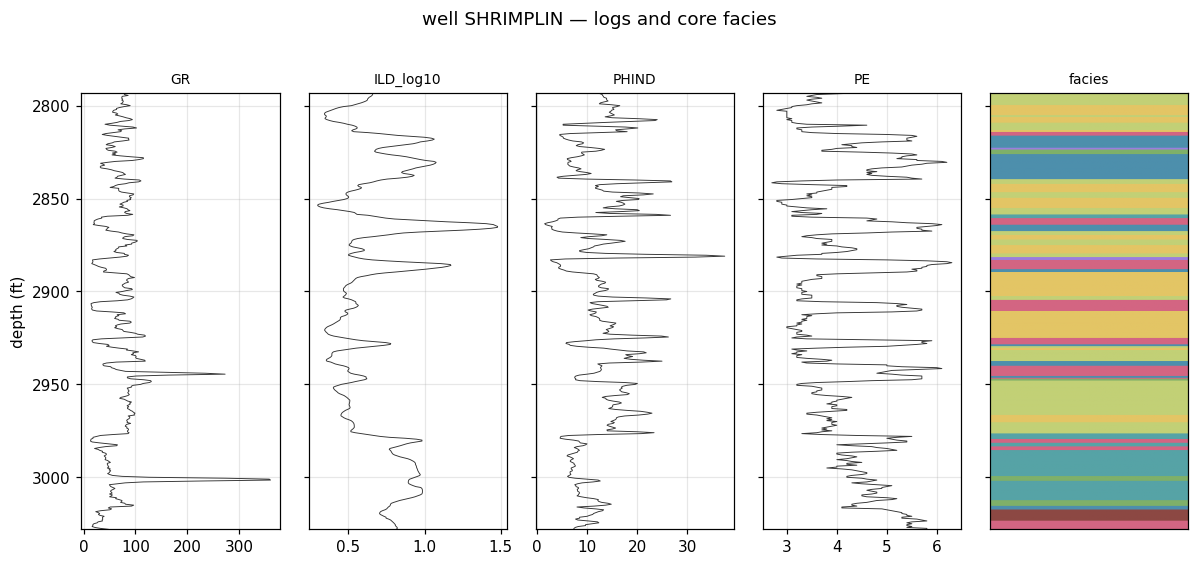

In [2]:
w = 'SHRIMPLIN'; g = train[train['Well Name']==w]
raw = pd.read_csv(DATA+'training_wells.csv'); g0 = raw[raw['Well Name']==w].sort_values('Depth')
fig, ax = plt.subplots(1, 5, figsize=(11, 5), sharey=True)
for a, log in zip(ax[:4], ['GR','ILD_log10','PHIND','PE']):
    a.plot(g0[log], g0['Depth'], lw=0.6, color='#333'); a.set_title(log, fontsize=9); a.invert_yaxis(); a.grid(alpha=0.3)
ax[0].set_ylabel('depth (ft)')
fc = g0['Facies'].to_numpy()[None,:].T
ax[4].imshow(fc, aspect='auto', cmap=fcmap, vmin=1, vmax=9,
             extent=[0,1,g0['Depth'].max(),g0['Depth'].min()]); ax[4].set_title('facies', fontsize=9); ax[4].set_xticks([])
fig.suptitle('well %s — logs and core facies' % w, y=1.02); plt.tight_layout(); plt.show()

## 2. A generative model of a facies

Each facies leaves a characteristic signature in log space — a cloud with its own centre and spread. We model
that cloud as a **multivariate Gaussian** and fit one per facies from the labelled training rows (a supervised,
closed-form fit). Together these are the *emission distributions* of the model to come: $p(\text{logs}\mid
\text{facies})$.

A real gotcha lurks here. The nonmarine/marine flag `NM_M` is **constant within some facies**, which makes
that facies' covariance **singular** — and a singular Gaussian gives nonsense densities. The fix is to model
only the genuinely continuous logs (we dropped `NM_M`); a covariance ridge guards the thin classes. This is a
small lesson with teeth: degenerate features quietly destroy generative models.

Iteration 2: ln[p_mat(Data|Model)]=-9.845748e+02, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-4.960211e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-4.827253e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-1.349789e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-1.755453e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-3.019356e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-8.855865e+02, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-4.288562e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
Iteration 2: ln[p_mat(Data|Model)]=-1.022584e+03, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=0.000000e+00
f

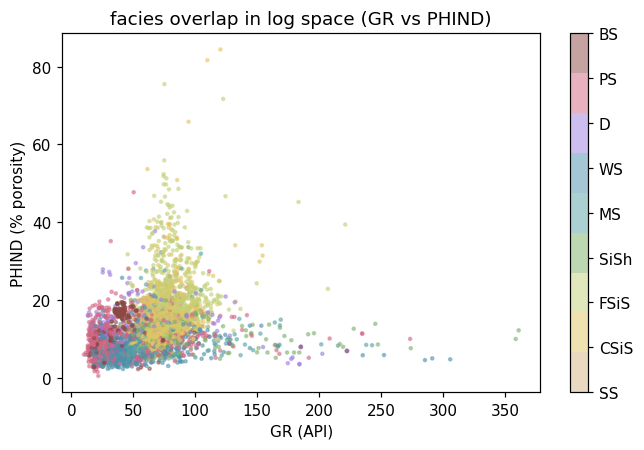

In [3]:
from mixle.inference import fit
from mixle.stats import MultivariateGaussianEstimator, HiddenMarkovModelDistribution

emissions = []
for f in FACIES:
    rows = train.loc[train['Facies']==f, LOGS].to_numpy(float)
    emissions.append(fit([r for r in rows], MultivariateGaussianEstimator(dim=K, ridge=1e-4), print_iter=0))
prior = train['Facies'].value_counts().reindex(FACIES).to_numpy(float); prior /= prior.sum()
print('fitted %d per-facies Gaussian emissions on %d logs' % (len(emissions), K))

# crossplot: GR vs PHIND coloured by facies — the overlapping clouds the classifier must separate
g0 = pd.read_csv(DATA+'training_wells.csv')
fig, ax = plt.subplots(figsize=(6.2, 4.2))
sctr = ax.scatter(g0['GR'], g0['PHIND'], c=g0['Facies'], cmap=fcmap, vmin=1, vmax=9, s=4, alpha=0.5)
ax.set(xlabel='GR (API)', ylabel='PHIND (% porosity)', title='facies overlap in log space (GR vs PHIND)')
cb = fig.colorbar(sctr, ticks=range(1,10)); cb.ax.set_yticklabels([FNAME[f] for f in FACIES]); plt.tight_layout(); plt.show()

## 3. Independent classification, and why it is not enough

The natural first move is a per-depth **Bayes classifier**: at each sample pick the facies maximizing
$p(\text{logs}\mid\text{facies})\,p(\text{facies})$. It treats every depth in isolation. We score it on the
**real blind wells** (STUART and CRAWFORD), aligning each logged depth to its core facies by nearest depth.

In [4]:
def attach_truth(b, c):
    c = c.sort_values('Depth.ft'); cd = c['Depth.ft'].to_numpy(); code = c['LithCode'].to_numpy()
    bd = b['Depth'].to_numpy(); j = np.clip(np.searchsorted(cd, bd), 0, len(cd)-1); jl = np.clip(j-1,0,len(cd)-1)
    nearest = np.where(np.abs(cd[jl]-bd) < np.abs(cd[j]-bd), jl, j)
    out = b.copy(); out['true_code'] = code[nearest]; out['join_dist'] = np.abs(cd[nearest]-bd); return out
blind = pd.concat([attach_truth(b, core[core['WellName']==w]) for w, b in blind.groupby('Well Name', sort=False)],
                  ignore_index=True)
blind = blind[blind['true_code'].isin(FACIES) & (blind['join_dist']<=0.5)].reset_index(drop=True)
y = blind['true_code'].to_numpy()
print('blind samples scored: %d (nearest-depth join, median dist 0 ft)' % len(blind))

Xall = blind[LOGS].to_numpy(float); loglik = np.empty((len(Xall), len(FACIES)))
for k, dist in enumerate(emissions):
    enc = dist.dist_to_encoder().seq_encode([r for r in Xall]); loglik[:, k] = dist.seq_log_density(enc)
baseline = np.array([FACIES[s] for s in np.argmax(loglik + np.log(prior), axis=1)])

def adjacent_acc(yt, yp):
    return np.mean([ (F2I[p] in ADJ[F2I[t]]) for t, p in zip(yt, yp) ])
print('independent baseline:  accuracy %.3f   macro-F1 %.3f   adjacent-acc %.3f'
      % (accuracy_score(y, baseline), f1_score(y, baseline, labels=FACIES, average='macro', zero_division=0),
         adjacent_acc(y, baseline)))

blind samples scored: 819 (nearest-depth join, median dist 0 ft)
independent baseline:  accuracy 0.360   macro-F1 0.235   adjacent-acc 0.719


## 4. Stratigraphy is Markovian

**Walther's law** of facies: the vertical succession of rock types in a conformable sequence mirrors the
lateral succession of depositional environments — so facies follow each other in an *ordered, predictable*
way, not at random. Statistically, the facies sequence down a well is close to a **Markov chain**: the next
facies depends mostly on the current one. We estimate the 9×9 transition matrix by counting facies-to-facies
steps within each training well.

Put the per-facies Gaussian *emissions* together with this *transition* structure and you have a **hidden
Markov model**: the facies are the hidden states, the logs are the emissions. Decoding it with **Viterbi**
finds the single most likely *sequence* of rock — which, unlike independent classification, cannot jump
through geologically impossible transitions. We build the HMM from the supervised components and decode each
blind well.

In [5]:
SMOOTH = 1.0
tc = np.full((len(FACIES),)*2, SMOOTH); ic = np.full(len(FACIES), SMOOTH)
for _, gw in train.groupby('Well Name', sort=False):
    seq = [F2I[f] for f in gw['Facies'].to_numpy()]; ic[seq[0]] += 1
    for a, b in zip(seq[:-1], seq[1:]): tc[a, b] += 1
transitions = tc / tc.sum(1, keepdims=True); pi = ic / ic.sum()
print('mean self-transition %.2f -> facies are "sticky" (beds persist)' % np.diag(transitions).mean())

hmm = HiddenMarkovModelDistribution(topics=emissions, w=pi, transitions=transitions)
hmm_state = np.full(len(blind), -1); post_full = np.zeros((len(blind), len(FACIES)))
for w, idx in blind.groupby('Well Name', sort=False).groups.items():
    seq = [r for r in blind.loc[idx, LOGS].to_numpy(float)]
    lp = hmm.latent_posterior(seq); pos = blind.index.get_indexer(idx)
    hmm_state[pos] = lp.mode()              # exact Viterbi (global-MAP sequence)
    post_full[pos] = lp.marginals()         # forward-backward per-depth posterior
hmm_pred = np.array([FACIES[s] for s in hmm_state])
print('HMM (Viterbi):         accuracy %.3f   macro-F1 %.3f   adjacent-acc %.3f'
      % (accuracy_score(y, hmm_pred), f1_score(y, hmm_pred, labels=FACIES, average='macro', zero_division=0),
         adjacent_acc(y, hmm_pred)))
print('\n  baseline -> HMM:  macro-F1 %.3f -> %.3f  (+%.1f%% relative)'
      % (f1_score(y, baseline, labels=FACIES, average='macro', zero_division=0),
         f1_score(y, hmm_pred, labels=FACIES, average='macro', zero_division=0),
         100*(f1_score(y, hmm_pred, labels=FACIES, average='macro', zero_division=0)/
              f1_score(y, baseline, labels=FACIES, average='macro', zero_division=0)-1)))

mean self-transition 0.82 -> facies are "sticky" (beds persist)
HMM (Viterbi):         accuracy 0.374   macro-F1 0.288   adjacent-acc 0.736

  baseline -> HMM:  macro-F1 0.235 -> 0.288  (+22.6% relative)


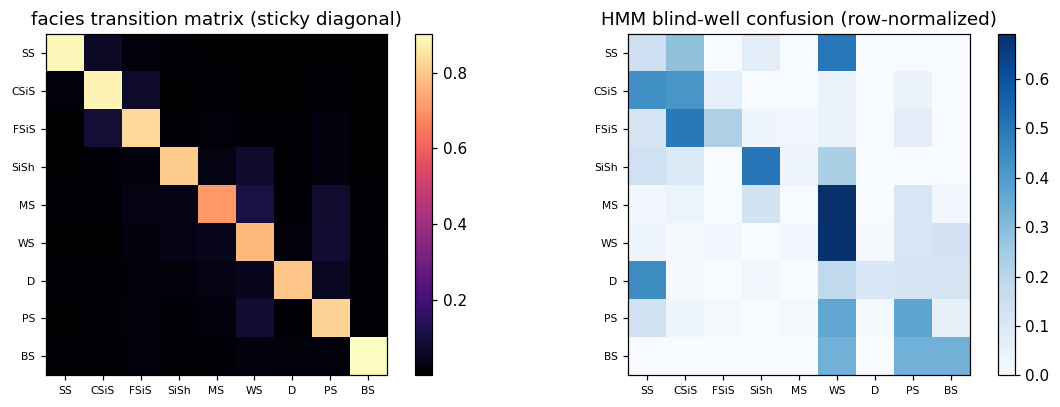

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
im = ax[0].imshow(transitions, cmap='magma'); ax[0].set(title='facies transition matrix (sticky diagonal)',
    xticks=range(9), yticks=range(9), xticklabels=[FNAME[f] for f in FACIES], yticklabels=[FNAME[f] for f in FACIES])
ax[0].tick_params(labelsize=7); fig.colorbar(im, ax=ax[0], fraction=0.046)
cm = confusion_matrix(y, hmm_pred, labels=FACIES)
im = ax[1].imshow(cm/cm.sum(1,keepdims=True), cmap='Blues'); ax[1].set(title='HMM blind-well confusion (row-normalized)',
    xticks=range(9), yticks=range(9), xticklabels=[FNAME[f] for f in FACIES], yticklabels=[FNAME[f] for f in FACIES])
ax[1].tick_params(labelsize=7); fig.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

The transition matrix is strongly diagonal — beds persist — and has a clear band structure: facies step to
their *neighbours* in the depositional ordering, rarely across it. The HMM raises blind-well macro-F1 by about
a quarter over independent classification and lifts adjacent-facies accuracy: most of its remaining errors
(off-diagonal mass in the confusion matrix) are confusions between *adjacent* facies, which are geologically
close. The gain is pure structure — no new logs, just the knowledge that rock is layered.

## 5. Uncertainty

A point prediction hides what the model does not know. The HMM's **forward–backward** pass returns, at every
depth, a full posterior probability over the nine facies, $q(\text{facies}_t \mid \text{all logs})$ — coherent
with the whole sequence, not just the local sample. Plotted down a blind well, this is a **probabilistic
facies log**: where the rock is unambiguous the posterior concentrates on one facies; at bed boundaries and in
ambiguous intervals it spreads, flagging where to distrust the answer.

But are the probabilities *honest*? We check **calibration** — does the model get, say, its "90%-confident"
predictions right 90% of the time? The answer here is instructive: it does **not**. The posteriors are
systematically **over-confident** (the calibration curve sits well below the diagonal; accuracy at high
confidence barely exceeds the average). This is the expected failure of crude single-Gaussian emissions plus
the model's conditional-independence assumption — both sharpen the posterior past what the data support. The
*ranking* of certainty is still useful (ambiguous zones really are ambiguous), but the raw numbers would need
**recalibration** (temperature scaling) before being read as true probabilities. Reporting this honestly is
the point: an uncalibrated posterior is a trap, and you only find it by checking against held-out truth.

mean posterior confidence 0.80 | accuracy where confidence>0.9: 0.380 (n=358) vs overall 0.374


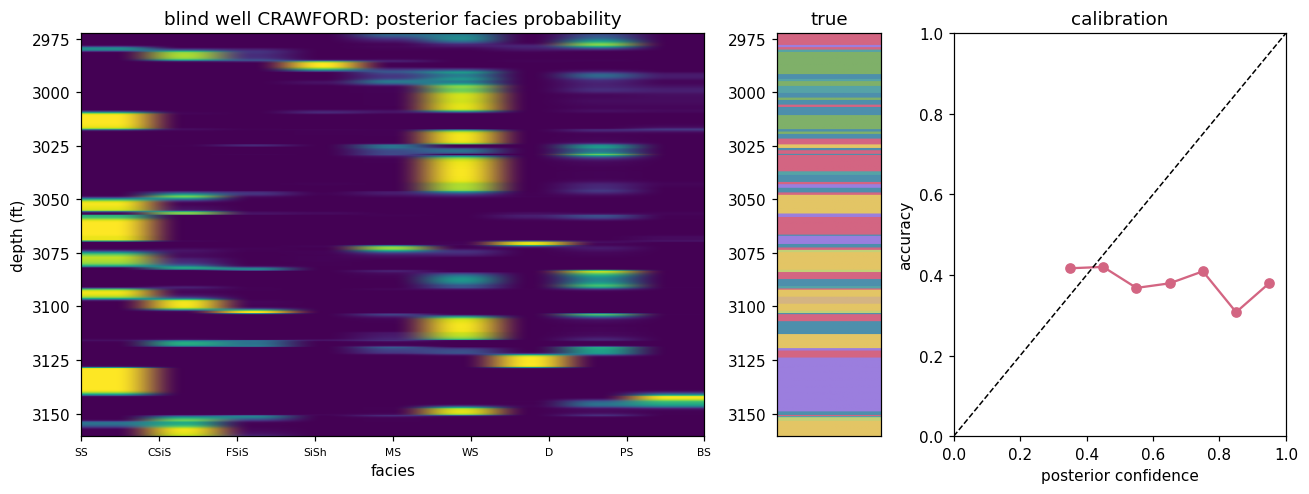

In [7]:
conf = post_full.max(1)
hi = conf > 0.9
print('mean posterior confidence %.2f | accuracy where confidence>0.9: %.3f (n=%d) vs overall %.3f'
      % (conf.mean(), accuracy_score(y[hi], hmm_pred[hi]), hi.sum(), accuracy_score(y, hmm_pred)))
# calibration curve
import numpy as np
bins = np.linspace(0,1,11); cal=[]
for lo,hib in zip(bins[:-1],bins[1:]):
    m=(conf>=lo)&(conf<hib)
    if m.sum()>5: cal.append((0.5*(lo+hib), accuracy_score(y[m], hmm_pred[m]), m.sum()))
cal=np.array(cal)

w = blind['Well Name'].unique()[0]; idx = blind['Well Name']==w
P = post_full[idx.to_numpy()]; d = blind.loc[idx,'Depth'].to_numpy(); yt = y[idx.to_numpy()]; yp = hmm_pred[idx.to_numpy()]
fig, ax = plt.subplots(1, 3, figsize=(12, 4.6), gridspec_kw={'width_ratios':[3,0.5,1.6]})
ax[0].imshow(P, aspect='auto', cmap='viridis', extent=[1,9,d.max(),d.min()], vmin=0, vmax=1)
ax[0].set(title='blind well %s: posterior facies probability'%w, xlabel='facies', ylabel='depth (ft)',
          xticks=range(1,10), xticklabels=[FNAME[f] for f in FACIES]); ax[0].tick_params(axis='x',labelsize=7)
ax[1].imshow(yt[:,None], aspect='auto', cmap=fcmap, vmin=1, vmax=9, extent=[0,1,d.max(),d.min()])
ax[1].set(title='true', xticks=[])
ax[2].plot(cal[:,0], cal[:,1], 'o-', color='#d36582'); ax[2].plot([0,1],[0,1],'k--',lw=1)
ax[2].set(title='calibration', xlabel='posterior confidence', ylabel='accuracy', xlim=(0,1), ylim=(0,1))
plt.tight_layout(); plt.show()

## 6. Petrophysics: imputing a missing log

The photoelectric log **PE** — the cleanest mineralogy indicator — is **missing for several wells** (the tool
was not always run). Rather than discard those wells or the log, we **reconstruct PE** from the logs that *are*
present, with a **Gaussian process** regression: PE as a smooth nonlinear function of (GR, resistivity,
porosity, position), learned where PE exists and predicted where it does not — crucially, **with a posterior
standard deviation**, so each imputed value comes with an honest error bar. We validate on held-out real PE
measurements.

GP PE imputation: held-out RMSE 0.464 (vs 0.896 predicting the mean); 95% interval coverage 0.87


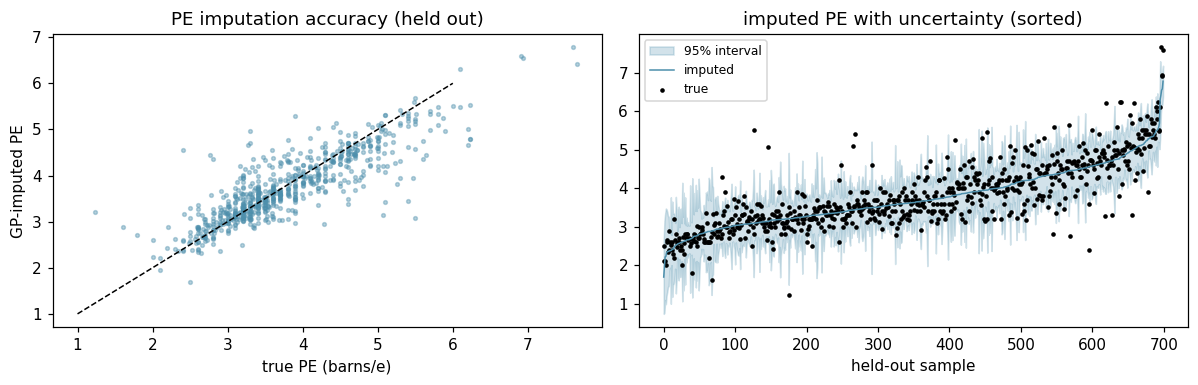

In [8]:
from mixle.models import GaussianProcessRegressor
have = pd.read_csv(DATA+'training_wells.csv').dropna(subset=['PE'])
Xp = have[LOGS].to_numpy(float); yp_ = have['PE'].to_numpy(float)
mp, sp = Xp.mean(0), Xp.std(0); Xn = (Xp-mp)/sp; ymn, ysd = yp_.mean(), yp_.std(); yn = (yp_-ymn)/ysd
rng = np.random.RandomState(0); o = rng.permutation(len(Xn)); tr_i, te_i = o[:1500], o[1500:2200]
gp = GaussianProcessRegressor(lengthscale=2.0, amplitude=1.0, noise=0.3, kernel='matern52')
gp.fit(Xn[tr_i], yn[tr_i], max_its=80, lr=0.05)
m, cov = gp.predict(Xn[tr_i], yn[tr_i], Xn[te_i], return_cov=True)
pred = m*ysd + ymn; psd = np.sqrt(np.clip(np.diag(cov), 0, None))*ysd
rmse = np.sqrt(np.mean((pred-yp_[te_i])**2))
inside = np.mean(np.abs(pred-yp_[te_i]) < 1.96*psd)
print('GP PE imputation: held-out RMSE %.3f (vs %.3f predicting the mean); 95%% interval coverage %.2f'
      % (rmse, yp_.std(), inside))
order = np.argsort(pred)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(yp_[te_i], pred, s=6, alpha=0.4, c='#4d8fac'); ax[0].plot([1,6],[1,6],'k--',lw=1)
ax[0].set(xlabel='true PE (barns/e)', ylabel='GP-imputed PE', title='PE imputation accuracy (held out)')
xs = np.arange(len(order))
ax[1].fill_between(xs, (pred-1.96*psd)[order], (pred+1.96*psd)[order], alpha=0.25, color='#4d8fac', label='95% interval')
ax[1].plot(xs, pred[order], color='#4d8fac', lw=1, label='imputed'); ax[1].scatter(xs, yp_[te_i][order], s=4, c='k', label='true')
ax[1].set(title='imputed PE with uncertainty (sorted)', xlabel='held-out sample'); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## Summary, limitations, and references

On **real** well logs from the Panoma field, with two **fully blind wells** as an honest test:

1. Each facies is a multivariate-Gaussian signature in log space (with a real lesson about singular features).
2. A per-depth Bayes classifier ignores that rock is layered and makes geologically impossible facies flips.
3. **Walther's law** makes the facies sequence Markovian; a hidden Markov model decodes the most likely *run*
   of rock and **raises blind-well macro-F1 by ~25%** over independent classification — pure structure, no new
   data.
4. The forward–backward posterior gives a **per-depth facies probability** — uncertainty a point prediction
   cannot — though checking it against held-out truth reveals the raw posteriors are **over-confident** and
   would need recalibration (an honest negative you only find by validating).
5. The missing **PE** log is reconstructed by a **Gaussian process** with honest error bars (held-out RMSE
   roughly half the naive baseline), validated on real measurements.

**Limitations.** Single-Gaussian emissions are crude — a Gaussian *mixture* per facies (or a discriminative
model) fits better; the contest's best entries reached higher accuracy with gradient boosting plus engineered
sequential features. We assumed a first-order, well-independent Markov chain (real successions have longer-range
order and formation-dependent transitions). The blind-well exact-match accuracy (~0.38) looks low because
raw 9-way facies matching is hard; adjacent-facies accuracy (the SEG metric) is far higher, and the *point* of
the notebook is the **relative** gain from sequence modeling and the **calibrated uncertainty**, not a leaderboard
score. Facies labels are themselves interpretive (core-to-log depth shifts, picking ambiguity).

**References.**
- B. Hall (2016), *Facies classification using machine learning*, The Leading Edge 35(10), 906–909. (the
  SEG-2016 contest and this dataset)
- M. K. Dubois et al. (2007), *Comparison of four approaches to a rock facies classification problem*,
  Computers & Geosciences 33(5), 599–617. (the original Panoma study)
- L. R. Rabiner (1989), *A tutorial on hidden Markov models…*, Proc. IEEE 77(2), 257–286.
- J. Walther (1894), *Einleitung in die Geologie als historische Wissenschaft.* (Walther's law of facies)
- C. E. Rasmussen & C. K. I. Williams (2006), *Gaussian Processes for Machine Learning.*

**Exercises.**
1. **Mixture emissions.** Replace each per-facies Gaussian with a 2–3 component Gaussian mixture; does
   blind-well accuracy rise?
2. **Posterior decoding vs Viterbi.** Compare the forward–backward MAP (per-depth argmax of the posterior) with
   the Viterbi sequence; when do they disagree, and which is better at bed boundaries?
3. **Impute then classify.** Add the GP-imputed PE (and its uncertainty) as a sixth feature; does mineralogy
   information improve facies recovery, and how do you propagate the imputation uncertainty?
4. **Formation-specific transitions.** Estimate a separate transition matrix per Formation; does conditioning
   the stratigraphy on the geological unit help?